[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMM_InSample_Regime_Analysis_EquityBond.ipynb)

# **Corrélation indices actions-obligations : Description des régimes de marchés entre le S&P et le T-Bond 10y de 70 à 2025**

Ce code est de la description pure (full in-sample). Il initialise un HMM et le fit sur les log returns du S&P et du T-Bond 10y de 1970 à 2025 et identifie 4 régimes de marchés distincts. Pour comprendre ce que représente un régime, on utilise un objet de type RegimeStatisticalAnalyzer pour afficher les moyennes, volatilités et corrélations entre actifs conditionnellement à ce régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-transfo pour les corrélations).


TO DO: rajouter le Box'M pour la matrice de cov complète





# Connection au github

In [5]:
import os
import sys

# 1. Vérification de l'environnement
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone du repo
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Déplacement dans le dossier du projet
    os.chdir(repo_name)

    # 4. Ajout du chemin au système pour l'import des modules .py
    sys.path.append(os.getcwd())

    print(f"Répertoire actuel : {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 600 (delta 141), reused 45 (delta 45), pack-reused 396 (from 3)
Receiving objects: 100% (600/600), 18.61 MiB | 31.34 MiB/s, done.
Resolving deltas: 100% (265/265), done.
Répertoire actuel : /content/CorrelationEquityBond/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [6]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-wl2ndhi7
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-wl2ndhi7
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


# Préparation des données

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_stat_app_vf_with_gold.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [8]:
ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
asset_names = ["S&P", "T-bond 10y"]
annualise_factor = np.sqrt(12) # mensuel

cols = ASSET_VARS
df_model = df[cols].dropna().copy()
Y_raw = df_model[ASSET_VARS].values.astype(float)

dates = df_model.index
split_date = pd.Timestamp("2025-01-01") # on fait de la description ici

train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01")) # on commence l'analyse en 70
dates_train = dates[train_mask]
Y_train_raw = Y_raw[train_mask]

T, D = Y_raw.shape
SEED = 120
np.random.seed(SEED)

data_to_fit = [Y_train_raw*100] # * 100 pour stabilité numérique


# Initialisation et fit du HMM descriptif

In [10]:
from RegimeDetector.HMMMarketRegimeDetector import HMMMarketRegimeDetector
from RegimeDetector.HMMCoherenceChecker import HMMCoherenceChecker

In [12]:
# Modèle HMM
detector = HMMMarketRegimeDetector(
    n_regimes=4,
    n_dim=2,
    random_state=42
)

detector.fit(observations=data_to_fit)
states = detector.viterbi_states

# Regarder la cohérence/stabilité du modèle
checker = HMMCoherenceChecker(
    detector=detector,
    log_returns=data_to_fit[0],
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.05
)

checker.report_emission_stats() # paramètres d'émission
for ref_idx in range(4):
  checker.report_transition_stats(ref_idx=ref_idx) # paramètres de transitioon

checker.final_verdict() # verdict final (automatisé)



DIAGNOSTIC COMPLET DES ÉMISSIONS (BOOTSTRAP & TESTS)

1. VOLATILITÉS ANNUELLES AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                        
0      S&P         20.7719      16.8046      24.4182
       T-bond 10y   6.3444       5.3222       7.2832
1      S&P          9.4785       8.6795      10.2704
       T-bond 10y   6.0848       5.5967       6.5182
2      S&P         16.5024      13.3366      19.2045
       T-bond 10y  13.5741      10.7680      15.9274
3      S&P          7.0228       6.2479       7.7247
       T-bond 10y   4.7945       4.2415       5.3242


2. CORRÉLATIONS AVEC INTERVALLES DE CONFIANCE :


,,Value,Lower_Bound,Upper_Bound
Regime,Label,,,
0,S&P / T-bond 10y,-0.4558,-0.6569,-0.2210
1,S&P / T-bond 10y,0.3873,0.3043,0.4644
2,S&P / T-bond 10y,0.2830,0.0785,0.4741
3,S&P / T-bond 10y,-0.1467,-0.3057,0.0176



3. TESTS DE SÉPARABILITÉ (TOUTES LES PAIRES) :
- Significativité des Volatilités (Levene) :


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,2.2864,0.6093,0.0002,True
1,Intercept,R0 -> R1,Base_Prob,-0.5282,1.0025,0.5983,False
2,Intercept,R0 -> R2,Base_Prob,-0.9240,0.9479,0.3297,False
3,Intercept,R1 -> R0,Base_Prob,0.4373,1.1098,0.6935,False
4,Intercept,R1 -> R1,Base_Prob,4.2535,0.8348,0.0000,True
5,Intercept,R1 -> R2,Base_Prob,-0.0773,1.2368,0.9502,False
6,Intercept,R2 -> R0,Base_Prob,0.0875,1.7392,0.9599,False
7,Intercept,R2 -> R1,Base_Prob,0.9676,1.4925,0.5168,False
8,Intercept,R2 -> R2,Base_Prob,3.4029,1.1994,0.0045,True
9,Intercept,R3 -> R0,Base_Prob,-2.8188,0.4965,0.0000,True



2. DYNAMIQUE MOYENNE ET PERSISTANCE :


,Durée_Moyenne (mois),Prob_Stationnaire,Prob_Rester
0,5.9528,0.1637,0.8320
1,21.2498,0.4615,0.9529
2,7.3630,0.1113,0.8642
3,11.3100,0.2635,0.9116



RAPPORT DE COHÉRENCE HMM : 80.56%
1. SÉPARABILITÉ : 72.2% (Seuil: 50%) -> OK
2. STABILITÉ    : VALIDE
3. PERSISTANCE  : 6.0 mois (min 3.0) -> OK
4. CONFIANCE    : 72.7% (Entropie) -> SOLIDE
--------------------------------------------------
DYNAMIQUE DES RÉGIMES :
    Durée   Fréq
0   5.953  0.164
1  21.250  0.461
2   7.363  0.111
3  11.310  0.263

VERDICT : MODÈLE VALIDÉ (Robuste)


np.float64(0.8056355505132586)

On semble donc identifier 4 régimes de marchés disincts

1.   Flight-to-quality (correl négative, haute vol, typique de 2008 ou 2020)
2.   Normal (correl positive, vol basse)
3.   Stress inflationniste (correl positive, haute vol, typique des années 70 ou de 2022)
4.   Diversification idéale (correl négative, vol basse vol, pré-2010)



Concernant les tests statistiques, les résultats de Levene et Fisher-Transfo sont convaincaints (au moins un des 2 est significatif pour chaque pair). Sur les paramètres de transition, pour tous les indices de références, les intercepts des transitions d'un régime vers lui-même sont significatifs. On peut surtout noter l'absence de valeurs propres négatives de l'info de Fisher et une entropie confirmée.

# Visualisation graphique

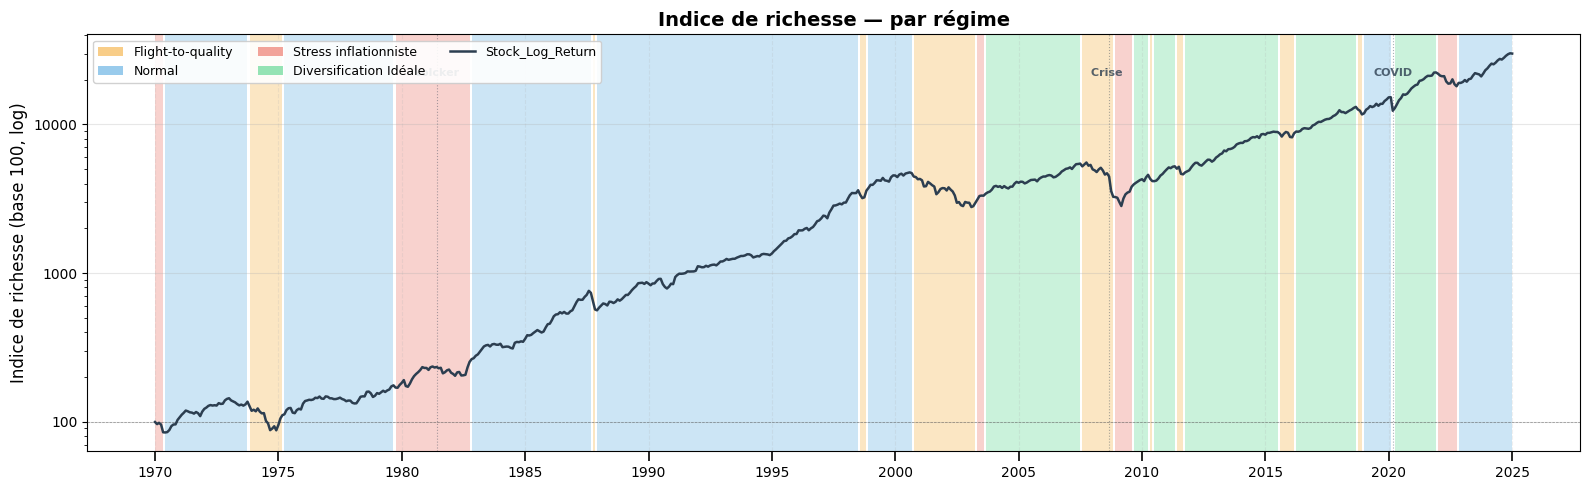

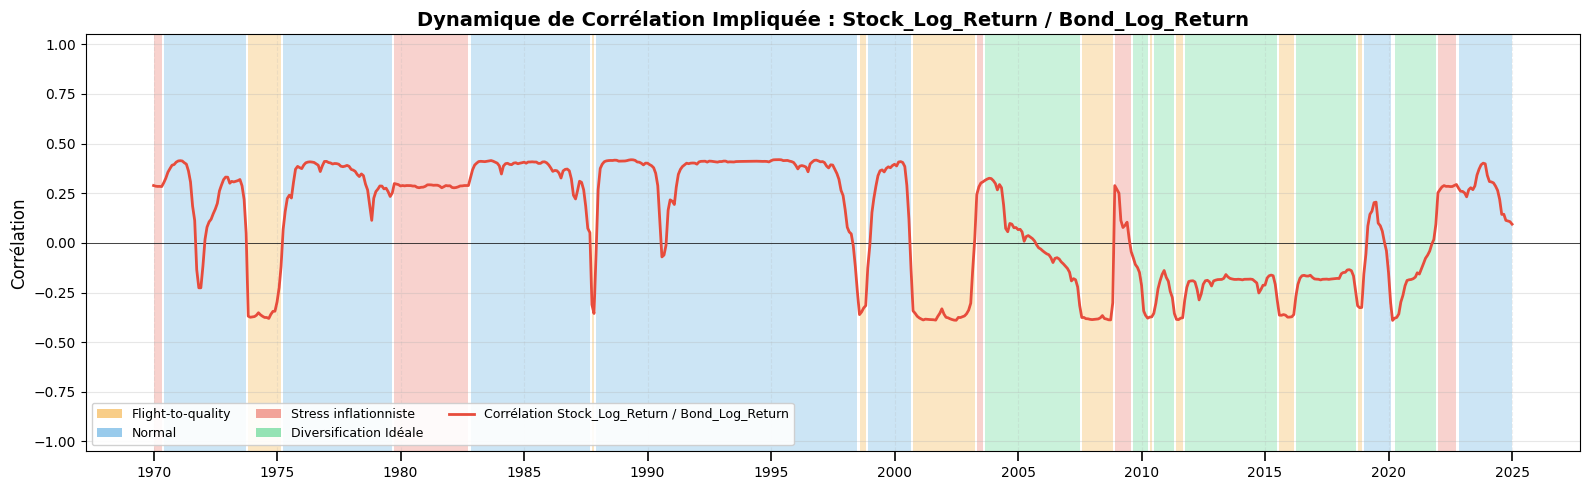

In [14]:
from RegimeDetector.RegimeReporter import RegimeReporter

mes_labels = {0: "Flight-to-quality", 1: "Normal", 2: "Stress inflationniste", 3: "Diversification Idéale"} # les 4 régimes identifiés
mes_couleurs = {0:"#f39c12", 1: "#3498db", 2: "#e74c3c", 3: "#2ecc71"} # choix des couleurs
mes_crises = {"Volcker": "1981-06-01", "Crise ": "2008-09-01","COVID": "2020-03-01",} # quelques dates pour les identifier + facilement

# Instanciation générique
visualizer = RegimeReporter(
    detector=detector,
    log_returns=data_to_fit[0],
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=mes_labels,
    regime_colors=mes_couleurs,
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()